# Multi-Agent Investment Research System

### AAI-520: Natural Language Processing and Generative AI  
### Final Team Project - Group 10

**Team Members:**  
Emma Bishop  
Pravin Suranthiran  

**University of San Diego**  
**Fall 2026**

## 1. Environment Setup

In this section, we import the Python libraries needed for data loading, preprocessing, sentiment analysis, evaluation, and market-data retrieval.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

c:\Users\18587\Documents\Projects\University of San Diego\AAI-520 Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


In [2]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"yfinance version: {yf.__version__}")
print("Environment setup is complete.")

Pandas version: 3.0.6
NumPy version: 2.0.2
yfinance version: 1.7.0
Environment setup is complete.


## 2. Data Sources

The pipeline consumes two sources, both documented in `docs/sources.md`. The Financial PhraseBank supplies the sentiment model's corpus: annotated financial-news sentences in four configurations that differ in the annotator agreement a label requires. Training uses `sentences_allagree` (2,259 unanimous-label sentences after deduplication). The `sentences_50agree` sentences that are absent from `sentences_allagree` form the disagreement tail (sentences with disputed labels) and are held out as the closest analogue to live headlines. Yahoo Finance supplies prices and volume, quarterly income statements, company metadata, and news search. The full analysis of these sources is in [01_eda.ipynb](01_eda.ipynb); its conclusions set the model configuration and caution rules used here. The cell below loads the two PhraseBank configurations the pipeline consumes.

In [3]:
# Corpus snapshot: the training set and the held-out disputed labels.
allagree_ds = load_dataset(
    "takala/financial_phrasebank",
    "sentences_allagree",
    trust_remote_code=True
)["train"]
phrasebank_df = allagree_ds.to_pandas()
label_names = allagree_ds.features["label"].names
phrasebank_df["sentiment"] = phrasebank_df["label"].map(
    dict(enumerate(label_names))
)
phrasebank_clean = (
    phrasebank_df
    .drop_duplicates(subset="sentence")
    .reset_index(drop=True)
)

fiftyagree_ds = load_dataset(
    "takala/financial_phrasebank",
    "sentences_50agree",
    trust_remote_code=True
)["train"]
fiftyagree_df = fiftyagree_ds.to_pandas()
fiftyagree_df["sentiment"] = fiftyagree_df["label"].map(
    dict(enumerate(fiftyagree_ds.features["label"].names))
)

disagreement_tail_size = int(
    (
        ~fiftyagree_df
        .drop_duplicates(subset="sentence")["sentence"]
        .isin(set(phrasebank_clean["sentence"]))
    ).sum()
)

display(
    phrasebank_clean["sentiment"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
    .to_frame("training sentences")
)
print(f"Training corpus (allagree, deduplicated): {len(phrasebank_clean)}")
print(
    f"Disagreement tail (disputed labels, held out): "
    f"{disagreement_tail_size}"
)

,training sentences
sentiment,
negative,303
neutral,1386
positive,570


Training corpus (allagree, deduplicated): 2259
Disagreement tail (disputed labels, held out): 2579


## 3. Multi-Agent System Design

We designed our Investment Research Agent as a coordinated system of specialized agents. A user provides a stock ticker, and the coordinator creates a research plan, selects the appropriate tools, routes information to specialist agents, and combines their findings into a final research brief.

Our system includes the following agents:

1. **Coordinator and Planning Agent:** Creates the research plan, routes tasks, and combines the results.
2. **News Analysis Agent:** Processes financial news, classifies sentiment, extracts important information, and summarizes recent developments.
3. **Market Analysis Agent:** Evaluates price movements, trading volume, daily returns, and moving averages.
4. **Earnings Analysis Agent:** Reviews company financials and earnings-related information.
5. **Evaluator Agent:** Scores the completed analysis and provides feedback for revision.
6. **Memory Component:** Stores brief notes from previous runs so the system can improve future analyses.

Together, these components demonstrate planning, dynamic tool use, self-reflection, learning across runs, prompt chaining, routing, and evaluator–optimizer workflows.

### 3.1 Coordinator and Planning Agent

The Coordinator Agent receives a stock ticker and creates a structured research plan. It determines which specialist agents and tools should be used before any analysis begins. This makes the workflow transparent and allows the system to adapt its plan to the requested research areas.

In [4]:
def create_research_plan(
    ticker,
    include_news=True,
    include_market=True,
    include_earnings=True
):
    """Create a structured research plan for a stock ticker."""
    ticker = ticker.strip().upper()

    if not ticker:
        raise ValueError("A valid stock ticker is required.")

    plan = {
        "ticker": ticker,
        "objective": f"Create an investment research brief for {ticker}.",
        "tasks": []
    }

    if include_market:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "Market Analysis Agent",
                "tool": "Yahoo Finance",
                "task": "Analyze prices, returns, volume, and moving averages."
            }
        )

    if include_news:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "News Analysis Agent",
                "tool": "Financial news and sentiment model",
                "task": "Process news, classify sentiment, and summarize key events."
            }
        )

    if include_earnings:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "Earnings Analysis Agent",
                "tool": "Yahoo Finance financial statements",
                "task": "Review earnings and company financial performance."
            }
        )

    plan["tasks"].append(
        {
            "step": len(plan["tasks"]) + 1,
            "agent": "Evaluator Agent",
            "tool": "Quality-scoring rubric",
            "task": "Evaluate and refine the completed research brief."
        }
    )

    return plan


research_plan = create_research_plan("AAPL")
research_plan

{'ticker': 'AAPL',
 'objective': 'Create an investment research brief for AAPL.',
 'tasks': [{'step': 1,
   'agent': 'Market Analysis Agent',
   'tool': 'Yahoo Finance',
   'task': 'Analyze prices, returns, volume, and moving averages.'},
  {'step': 2,
   'agent': 'News Analysis Agent',
   'tool': 'Financial news and sentiment model',
   'task': 'Process news, classify sentiment, and summarize key events.'},
  {'step': 3,
   'agent': 'Earnings Analysis Agent',
   'tool': 'Yahoo Finance financial statements',
   'task': 'Review earnings and company financial performance.'},
  {'step': 4,
   'agent': 'Evaluator Agent',
   'tool': 'Quality-scoring rubric',
   'task': 'Evaluate and refine the completed research brief.'}]}

### 3.2 Routing Workflow

The routing workflow examines the content of a research request and directs it to the most appropriate specialist. Market-related requests go to the Market Analysis Agent, news-related requests go to the News Analysis Agent, and financial-performance requests go to the Earnings Analysis Agent. Unclear requests return to the Coordinator Agent for further planning.

In [5]:
def route_research_request(request):
    """Route a research request to the appropriate specialist agent."""
    request_text = request.lower()

    routing_keywords = {
        "Market Analysis Agent": [
            "price", "volume", "return", "volatility",
            "moving average", "market"
        ],
        "News Analysis Agent": [
            "news", "headline", "sentiment", "announcement",
            "event", "article"
        ],
        "Earnings Analysis Agent": [
            "earnings", "revenue", "profit", "financial",
            "income", "balance sheet"
        ]
    }

    scores = {
        agent: sum(
            keyword in request_text
            for keyword in keywords
        )
        for agent, keywords in routing_keywords.items()
    }

    selected_agent = max(scores, key=scores.get)

    if scores[selected_agent] == 0:
        selected_agent = "Coordinator Agent"

    return {
        "request": request,
        "selected_agent": selected_agent,
        "routing_scores": scores
    }


sample_requests = [
    "Analyze recent price changes and trading volume.",
    "Summarize the latest company news and sentiment.",
    "Review revenue, profit, and quarterly earnings."
]

routing_results = [
    route_research_request(request)
    for request in sample_requests
]

routing_results

[{'request': 'Analyze recent price changes and trading volume.',
  'selected_agent': 'Market Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 2,
   'News Analysis Agent': 0,
   'Earnings Analysis Agent': 0}},
 {'request': 'Summarize the latest company news and sentiment.',
  'selected_agent': 'News Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 0,
   'News Analysis Agent': 2,
   'Earnings Analysis Agent': 0}},
 {'request': 'Review revenue, profit, and quarterly earnings.',
  'selected_agent': 'Earnings Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 0,
   'News Analysis Agent': 0,
   'Earnings Analysis Agent': 3}}]

### 3.3 Market Analysis Agent

The Market Analysis Agent dynamically retrieves historical stock data from Yahoo Finance. It calculates price change, annualized volatility, average trading volume, and moving averages. It then uses these indicators to identify the stock’s current market trend.

In [6]:
def market_analysis_agent(ticker, period="1y"):
    """Retrieve market data and calculate key market indicators."""
    ticker = ticker.strip().upper()
    stock_data = yf.Ticker(ticker).history(
        period=period,
        interval="1d",
        auto_adjust=True
    )

    if stock_data.empty:
        raise ValueError(f"No market data was returned for {ticker}.")

    closing_prices = stock_data["Close"].dropna()
    daily_returns = closing_prices.pct_change().dropna()

    first_price = closing_prices.iloc[0]
    latest_price = closing_prices.iloc[-1]
    period_return = ((latest_price / first_price) - 1) * 100
    annualized_volatility = daily_returns.std() * np.sqrt(252) * 100
    average_volume = stock_data["Volume"].mean()

    average_20 = closing_prices.rolling(window=20).mean().iloc[-1]
    average_50 = closing_prices.rolling(window=50).mean().iloc[-1]

    if latest_price > average_20 > average_50:
        trend = "Bullish"
    elif latest_price < average_20 < average_50:
        trend = "Bearish"
    else:
        trend = "Mixed"

    return {
        "ticker": ticker,
        "period": period,
        "latest_price": round(float(latest_price), 2),
        "period_return_percent": round(float(period_return), 2),
        "annualized_volatility_percent": round(
            float(annualized_volatility),
            2
        ),
        "average_daily_volume": round(float(average_volume)),
        "20_day_average": round(float(average_20), 2),
        "50_day_average": round(float(average_50), 2),
        "trend": trend,
        "tool_used": "Yahoo Finance"
    }


market_analysis = market_analysis_agent("AAPL")
market_analysis

{'ticker': 'AAPL',
 'period': '1y',
 'latest_price': 336.67,
 'period_return_percent': 30.94,
 'annualized_volatility_percent': 24.74,
 'average_daily_volume': 48085331,
 '20_day_average': 334.48,
 '50_day_average': 322.24,
 'trend': 'Bullish',
 'tool_used': 'Yahoo Finance'}

### 3.4 Earnings Analysis Agent

The Earnings Analysis Agent retrieves the company’s quarterly income statement from Yahoo Finance. It extracts important financial measures, including revenue, net income, and earnings per share. When prior-quarter data is available, it also calculates revenue growth.

In [7]:
def earnings_analysis_agent(ticker):
    """Retrieve and analyze recent quarterly earnings data."""
    ticker = ticker.strip().upper()
    stock = yf.Ticker(ticker)
    income_statement = stock.quarterly_income_stmt

    if income_statement.empty:
        raise ValueError(
            f"No quarterly income statement was returned for {ticker}."
        )

    latest_quarter = income_statement.columns[0]
    previous_quarter = (
        income_statement.columns[1]
        if len(income_statement.columns) > 1
        else None
    )

    def get_financial_value(row_name, quarter):
        if row_name in income_statement.index and quarter is not None:
            value = income_statement.loc[row_name, quarter]
            if pd.notna(value):
                return float(value)
        return None

    latest_revenue = get_financial_value(
        "Total Revenue",
        latest_quarter
    )
    previous_revenue = get_financial_value(
        "Total Revenue",
        previous_quarter
    )
    net_income = get_financial_value(
        "Net Income",
        latest_quarter
    )
    diluted_eps = get_financial_value(
        "Diluted EPS",
        latest_quarter
    )

    revenue_growth = None
    if latest_revenue is not None and previous_revenue:
        revenue_growth = (
            (latest_revenue / previous_revenue) - 1
        ) * 100

    return {
        "ticker": ticker,
        "latest_quarter": str(latest_quarter.date()),
        "revenue": latest_revenue,
        "net_income": net_income,
        "diluted_eps": diluted_eps,
        "quarterly_revenue_growth_percent": (
            round(revenue_growth, 2)
            if revenue_growth is not None
            else None
        ),
        "tool_used": "Yahoo Finance quarterly income statement"
    }


earnings_analysis = earnings_analysis_agent("AAPL")
earnings_analysis

{'ticker': 'AAPL',
 'latest_quarter': '2026-06-30',
 'revenue': 109417000000.0,
 'net_income': 29789000000.0,
 'diluted_eps': 2.02,
 'quarterly_revenue_growth_percent': -1.59,
 'tool_used': 'Yahoo Finance quarterly income statement'}

### 3.5 Ticker Resolution Agent

Because the system accepts any ticker, company-specific filter terms are derived at run time from Yahoo Finance metadata. `yf.Ticker(t).info` supplies the company names; the terms are the leading company name after corporate-suffix stripping, plus the symbol itself. When metadata is unavailable (delisted or thinly covered symbols), the agent returns no terms; the news relevance filter then widens, and the brief discloses the widened filter as a risk consideration (Section 5). The probe below runs a mixed basket: large caps, a punctuated ticker, a foreign ADR, an ampersand name, an invalid symbol.

In [8]:
import re

# Corporate suffixes stripped before taking the leading company name.
SUFFIXES = r"(inc|corp|corporation|ltd|plc|co|company|holdings|group|ag|se|nv|sa)\.?$"


def resolve_ticker_terms(ticker):
    """Resolve a ticker to news-filter terms from Yahoo Finance metadata."""
    ticker = ticker.strip().upper()

    try:
        info = yf.Ticker(ticker).info or {}
    except Exception:
        info = {}

    terms = set()
    for name in {info.get("shortName"), info.get("longName")} - {None, ""}:
        base = re.sub(r"[^\w\s]", " ", str(name).lower())
        base = re.sub(SUFFIXES, "", base.strip()).strip()
        if base and len(base.split()[0]) > 1:
            terms.add(base.split()[0])

    if info.get("symbol"):
        terms.add(re.escape(info["symbol"].lower()))

    return [rf"\b{term}\b" for term in sorted(terms)]


def probe_ticker_resolution(tickers):
    """Report which tickers resolve to filter terms via metadata alone."""
    records = []
    for candidate in tickers:
        try:
            terms = resolve_ticker_terms(candidate)
        except Exception:
            terms = []
        records.append(
            {
                "ticker": candidate,
                "filter_terms": ", ".join(terms) or "",
                "resolved": bool(terms),
            }
        )
    return pd.DataFrame(records)


probe_basket = ["AAPL", "MSFT", "NVDA", "TSLA", "BRK-B", "SAP", "JNJ", "ZZZZ"]
probe_results = probe_ticker_resolution(probe_basket)

print(
    f"Resolved through metadata alone: "
    f"{int(probe_results['resolved'].sum())} of {len(probe_results)}"
)
display(probe_results)

apple_terms = resolve_ticker_terms("AAPL")
print(f"Runtime-resolved filter terms for AAPL: {apple_terms}")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZZZZ"}}}


Resolved through metadata alone: 7 of 8


,ticker,filter_terms,resolved
0,AAPL,"\baapl\b, \bapple\b",True
1,MSFT,"\bmicrosoft\b, \bmsft\b",True
2,NVDA,"\bnvda\b, \bnvidia\b",True
3,TSLA,"\btesla\b, \btsla\b",True
4,BRK-B,"\bberkshire\b, \bbrk\-b\b",True
5,SAP,\bsap\b,True
6,JNJ,"\bjnj\b, \bjohnson\b",True
7,ZZZZ,,False


Runtime-resolved filter terms for AAPL: ['\\baapl\\b', '\\bapple\\b']


### 3.6 Financial Sentiment Model

We train a financial sentiment classifier using the cleaned Financial PhraseBank dataset. We use TF-IDF to convert financial text into numerical features and logistic regression to classify each sentence as negative, neutral, or positive. We use stratified splitting and balanced class weights because the dataset contains more neutral examples than positive or negative examples.

The model trains on the Financial PhraseBank `sentences_allagree` configuration (2,259 unanimous-label sentences after deduplication): TF-IDF over word unigrams and bigrams with sublinear scaling, class-weighted logistic regression, and macro-F1 as the primary metric (the corpus is roughly 60% neutral / 28% positive / 12% negative). Two pairs of numbers, both computed in this notebook: clean held-out text reaches 0.894 accuracy / 0.862 macro-F1; the 2,579-sentence disagreement tail (`sentences_50agree` minus `sentences_allagree`) falls to 0.621 / 0.479, with about 80% of tail predictions neutral. 01_eda.ipynb reports 0.620 / 0.473 for the same transfer; its model is refit on the full corpus rather than this notebook's 80% split. The tail numbers are the expected operating point on live headlines; confidence is calibrated below, and low-confidence headlines are abstained from in Section 3.9.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

x_train, x_test, y_train, y_test = train_test_split(
    phrasebank_clean["sentence"],
    phrasebank_clean["sentiment"],
    test_size=0.20,
    stratify=phrasebank_clean["sentiment"],
    random_state=42
)

sentiment_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True,
                max_features=10_000
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
).fit(x_train, y_train)

sentiment_predictions = sentiment_model.predict(x_test)

print(f"Training sentences: {len(x_train)}")
print(f"Held-out sentences: {len(x_test)}")

Training sentences: 1807
Held-out sentences: 452


Accuracy: 0.894
Macro-F1: 0.862

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.85      0.83        61
     neutral       0.95      0.93      0.94       277
    positive       0.82      0.82      0.82       114

    accuracy                           0.89       452
   macro avg       0.86      0.87      0.86       452
weighted avg       0.90      0.89      0.89       452



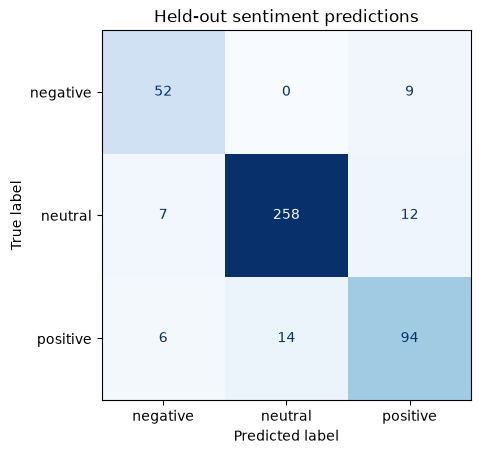

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

sentiment_accuracy = accuracy_score(y_test, sentiment_predictions)
sentiment_macro_f1 = f1_score(
    y_test, sentiment_predictions, average="macro"
)

print(f"Accuracy: {sentiment_accuracy:.3f}")
print(f"Macro-F1: {sentiment_macro_f1:.3f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        sentiment_predictions,
        zero_division=0
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    sentiment_predictions,
    cmap="Blues",
    colorbar=False
)
plt.title("Held-out sentiment predictions")
plt.show()

In [11]:
# Transfer to the disagreement tail: 50agree sentences absent from allagree.
disagreement_tail = (
    fiftyagree_df
    .drop_duplicates(subset="sentence")
    .loc[lambda frame: ~frame["sentence"].isin(
        set(phrasebank_clean["sentence"])
    )]
    .reset_index(drop=True)
)

tail_predictions = sentiment_model.predict(
    disagreement_tail["sentence"]
)

print(f"Disagreement-tail sentences: {len(disagreement_tail)}")
print(
    f"Tail accuracy: "
    f"{accuracy_score(disagreement_tail['sentiment'], tail_predictions):.3f}"
)
print(
    f"Tail macro-F1: "
    f"{f1_score(disagreement_tail['sentiment'], tail_predictions, average='macro'):.3f}"
)
print(
    f"Neutral share of tail predictions: "
    f"{np.mean(tail_predictions == 'neutral'):.3f}"
)

Disagreement-tail sentences: 2579
Tail accuracy: 0.621
Tail macro-F1: 0.479
Neutral share of tail predictions: 0.796


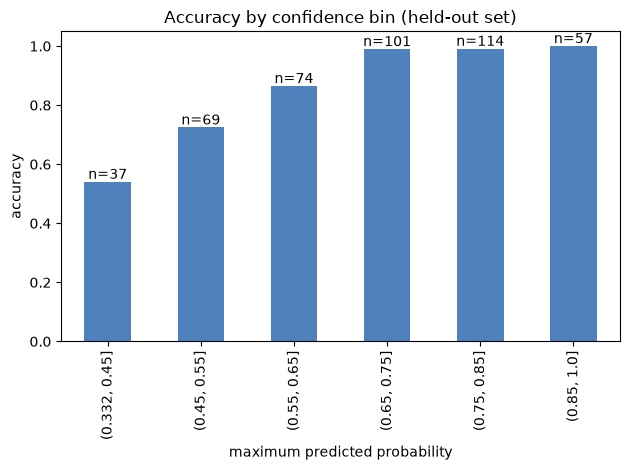

Expected calibration error: 0.215
Accuracy below 0.60 confidence: 0.704 (142 predictions)
Accuracy at or above 0.60 confidence: 0.981 (310 predictions)


,accuracy,count,mean_confidence,|accuracy - confidence|
bin,,,,
"(0.332, 0.45]",0.541,37,0.405,0.136
"(0.45, 0.55]",0.725,69,0.505,0.219
"(0.55, 0.65]",0.865,74,0.600,0.265
"(0.65, 0.75]",0.990,101,0.705,0.285
"(0.75, 0.85]",0.991,114,0.797,0.194
"(0.85, 1.0]",1.000,57,0.888,0.112


In [12]:
# Calibration: does reported confidence track correctness?
probabilities = sentiment_model.predict_proba(x_test)
confidence = probabilities.max(axis=1)
predictions_correct = (sentiment_predictions == y_test.to_numpy())

calibration_frame = pd.DataFrame(
    {"confidence": confidence, "correct": predictions_correct}
)
calibration_frame["bin"] = pd.cut(
    confidence,
    bins=[1 / 3, 0.45, 0.55, 0.65, 0.75, 0.85, 1.0],
    include_lowest=True
)

# Expected calibration error compares per-bin accuracy with the bin's
# mean confidence, the quantity the model actually reported.
calibration = (
    calibration_frame
    .groupby("bin", observed=True)
    .agg(
        accuracy=("correct", "mean"),
        count=("correct", "size"),
        mean_confidence=("confidence", "mean"),
    )
)
calibration["|accuracy - confidence|"] = (
    calibration["accuracy"] - calibration["mean_confidence"]
).abs()

expected_calibration_error = (
    (calibration["count"] / calibration["count"].sum())
    * calibration["|accuracy - confidence|"]
).sum()

ax = calibration["accuracy"].plot.bar(
    color="#4f81bd", title="Accuracy by confidence bin (held-out set)"
)
ax.set_xlabel("maximum predicted probability")
ax.set_ylabel("accuracy")
for i, (_, row) in enumerate(calibration.iterrows()):
    ax.text(i, row["accuracy"] + 0.01, f"n={int(row['count'])}", ha="center")
plt.tight_layout()
plt.show()

low_confidence = confidence < 0.60
print(f"Expected calibration error: {expected_calibration_error:.3f}")
print(
    f"Accuracy below 0.60 confidence: "
    f"{predictions_correct[low_confidence].mean():.3f} "
    f"({int(low_confidence.sum())} predictions)"
)
print(
    f"Accuracy at or above 0.60 confidence: "
    f"{predictions_correct[~low_confidence].mean():.3f} "
    f"({int((~low_confidence).sum())} predictions)"
)
display(calibration.round(3))

#### Zero-Shot LLM Comparison

A single batched Gemini call (temperature zero, one request rather than twenty) classifies the same held-out sentences zero-shot; the cell reports both accuracies on the comparable prefix and the agreement rate.

In [13]:
import json
import os
from pathlib import Path

from dotenv import load_dotenv


def find_env_file():
    """Locate .env by walking up from the working directory."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".env").exists():
            return candidate / ".env"
    return None


load_dotenv(find_env_file())
gemini_api_key = os.getenv("GEMINI_API_KEY")

if not gemini_api_key:
    print(
        "GEMINI_API_KEY not set - Gemini comparison skipped; "
        "the classical baseline above stands alone."
    )
else:
    from google import genai
    from google.genai import types

    gemini_client = genai.Client(api_key=gemini_api_key)
    comparison_sample = x_test.sample(20, random_state=42)
    classical_labels = np.asarray(sentiment_model.predict(comparison_sample))
    true_labels = y_test.loc[comparison_sample.index].to_numpy()

    numbered_sentences = "\n".join(
        f"{i + 1}. {sentence}"
        for i, sentence in enumerate(comparison_sample)
    )
    batch_prompt = (
        "Classify the sentiment of each numbered financial news "
        "sentence as positive, neutral, or negative.\n"
        "Respond with JSON only, no prose: "
        '{"labels": ["positive", ...]} with exactly one label per '
        "sentence, in order.\n\n"
        f"{numbered_sentences}"
    )
    reply = gemini_client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=batch_prompt,
        config=types.GenerateContentConfig(temperature=0.0),
    ).text

    try:
        payload = json.loads(reply[reply.find("{"):reply.rfind("}") + 1])
        gemini_labels = [str(label).lower() for label in payload.get("labels", [])]
    except (json.JSONDecodeError, AttributeError):
        gemini_labels = []

    n_comparable = min(len(gemini_labels), len(comparison_sample))
    if n_comparable < len(comparison_sample):
        print(
            f"Gemini returned {n_comparable} of {len(comparison_sample)} "
            "usable labels; both accuracies below use the comparable "
            "prefix only."
        )

    display(pd.DataFrame({
        "sentence": comparison_sample.to_numpy()[:8],
        "classical": classical_labels[:8],
        "gemini": gemini_labels[:8],
        "true": true_labels[:8],
    }))
    if n_comparable:
        comparable_true = true_labels[:n_comparable]
        print(
            f"Classical accuracy on comparable sample: "
            f"{np.mean(classical_labels[:n_comparable] == comparable_true):.2f}"
        )
        print(
            f"Gemini accuracy on comparable sample: "
            f"{np.mean(np.array(gemini_labels[:n_comparable]) == comparable_true):.2f}"
        )
        print(
            f"Classical-Gemini agreement: "
            f"{np.mean(np.array(gemini_labels[:n_comparable]) == classical_labels[:n_comparable]):.2f}"
        )
    else:
        print(
            "Gemini returned no usable labels; comparison skipped. "
            f"Classical accuracy on sample: "
            f"{np.mean(classical_labels == true_labels):.2f}"
        )

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


,sentence,classical,gemini,true
0,"Both operating profit and net sales for the six-month period increased , respectively from EUR0 .4 m and EUR3 .2 m , as compared to the correspond...",positive,positive,positive
1,"Under the deal , Know IT will pay SEK90m ( USD12 .8 m-EUR8 .6 m ) in cash and stock .",neutral,neutral,neutral
2,"2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pre...",negative,negative,negative
3,"The company also appointed Leif Rosen head of the Special Plate unit which includes the quarto plate units in Degerfors , Sweden , and New Castle ...",neutral,neutral,neutral
4,The fair value of CapMan Plc 's own investments on 30 September 2008 amounted to MEUR 59.8 .,neutral,neutral,neutral
5,"Aspocomp Group , headquartered in Helsinki , Finland , develops interconnection solutions for the electronics industry .",neutral,neutral,neutral
6,The bond has a value of EUR150m and a maturity of 4 years .,neutral,neutral,neutral
7,The customers will have an access to integrated propeller and gear packages from one source .,neutral,positive,neutral


Classical accuracy on comparable sample: 1.00
Gemini accuracy on comparable sample: 0.90
Classical-Gemini agreement: 0.90


### 3.7 News Prompt-Chaining Workflow

The News Analysis Agent follows the required prompt-chaining sequence: ingest news, preprocess the text, classify sentiment, extract important information, and summarize the results. Each stage passes its output to the next stage.

In [14]:
def ingest_financial_news(ticker, max_articles=10):
    """Retrieve and organize recent financial news from Yahoo Finance."""
    ticker = ticker.strip().upper()

    # Search Yahoo Finance directly for recent ticker news
    search_results = yf.Search(
        ticker,
        news_count=max_articles
    )

    raw_news = search_results.news or []
    articles = []

    for item in raw_news:
        title = item.get("title")
        publisher = item.get("publisher")
        link = item.get("link")
        summary = (
            item.get("summary")
            or item.get("description")
            or ""
        )

        if title:
            articles.append(
                {
                    "ticker": ticker,
                    "title": title,
                    "summary": summary,
                    "publisher": publisher,
                    "link": link
                }
            )

    return pd.DataFrame(articles)


news_df = ingest_financial_news("AAPL")

print(f"News articles retrieved: {len(news_df)}")
display(news_df.head())

News articles retrieved: 9


,ticker,title,summary,publisher,link
0,AAPL,"Apple, IBD Stock Of The Day, Rises Near Buy Points Ahead Of Smart Home Launch",,Investor's Business Daily,https://finance.yahoo.com/m/f4d24672-6d61-34bb-bcea-3ad5e39f9139/apple%2C-ibd-stock-of-the-day%2C.html
1,AAPL,"The tech industry wants you to run AI models at home, but it's not for everyone",,Yahoo Finance,https://finance.yahoo.com/technology/article/the-tech-industry-wants-you-to-run-ai-models-at-home-but-its-not-for-everyone-195314548.html
2,AAPL,"Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL And CRWD As Top AI Picks",,Stocktwits,https://finance.yahoo.com/technology/ai/articles/dan-ives-thinks-ai-buildout-190018254.html
3,AAPL,"Microsoft debuts Nvidia-powered Surface Laptop Ultra, as it aims for AI market",,Yahoo Finance,https://finance.yahoo.com/technology/article/microsoft-debuts-nvidia-powered-surface-laptop-ultra-as-it-aims-for-ai-market-185630649.html
4,AAPL,Apple Is Taking Another Shot at the Smart Home,,GuruFocus.com,https://finance.yahoo.com/technology/articles/apple-taking-another-shot-smart-184238425.html


#### News Preprocessing and Sentiment Classification

The News Analysis Agent cleans each article’s text and combines the title with the available summary. It then passes the processed text to our trained financial sentiment model, producing a sentiment label and confidence score for each article.

In [15]:
def preprocess_news(news_data):
    """Clean and combine news titles and summaries."""
    processed_news = news_data.copy()

    processed_news["text"] = (
        processed_news["title"].fillna("")
        + ". "
        + processed_news["summary"].fillna("")
    )

    processed_news["text"] = (
        processed_news["text"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return processed_news


def classify_news_sentiment(news_data, model):
    """Predict sentiment and confidence for each news article."""
    classified_news = news_data.copy()

    classified_news["sentiment"] = model.predict(
        classified_news["text"]
    )

    probabilities = model.predict_proba(
        classified_news["text"]
    )

    classified_news["confidence"] = (
        probabilities.max(axis=1).round(3)
    )

    return classified_news


processed_news_df = preprocess_news(news_df)

classified_news_df = classify_news_sentiment(
    processed_news_df,
    sentiment_model
)

display(
    classified_news_df[
        ["title", "publisher", "sentiment", "confidence"]
    ]
)

,title,publisher,sentiment,confidence
0,"Apple, IBD Stock Of The Day, Rises Near Buy Points Ahead Of Smart Home Launch",Investor's Business Daily,neutral,0.556
1,"The tech industry wants you to run AI models at home, but it's not for everyone",Yahoo Finance,neutral,0.717
2,"Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL And CRWD As Top AI Picks",Stocktwits,neutral,0.688
3,"Microsoft debuts Nvidia-powered Surface Laptop Ultra, as it aims for AI market",Yahoo Finance,neutral,0.620
4,Apple Is Taking Another Shot at the Smart Home,GuruFocus.com,neutral,0.811
5,Micron’s 107% Upside Scenario Depends on Precisely 1 Thing,TIKR,neutral,0.586
6,Apple Stocks Rise as $400 Target Reprices Siri AI,GuruFocus.com,neutral,0.596
7,Broadcom vs. Qualcomm: Rapid Growth vs. Flat Revenue,Motley Fool,positive,0.449
8,3 Ways New Investors Get Apple Stock Wrong,MoneyLion,neutral,0.531


#### News Relevance Filtering

Yahoo Finance search results may occasionally contain stories about other companies. The agent therefore filters the retrieved articles for company-specific terms before producing its final news analysis.

In [16]:
def filter_relevant_news(news_data, company_terms):
    """Keep articles containing at least one company-specific term."""
    search_pattern = "|".join(company_terms)

    relevant_mask = news_data["text"].str.contains(
        search_pattern,
        case=False,
        regex=True,
        na=False
    )

    return news_data.loc[relevant_mask].reset_index(drop=True)


# Company terms come from the Ticker Resolution Agent (Section 3.5).

relevant_news_df = filter_relevant_news(
    classified_news_df,
    apple_terms
)

print(
    f"Relevant Apple articles retained: "
    f"{len(relevant_news_df)} of {len(classified_news_df)}"
)

display(
    relevant_news_df[
        ["title", "publisher", "sentiment", "confidence"]
    ]
)

Relevant Apple articles retained: 5 of 9


,title,publisher,sentiment,confidence
0,"Apple, IBD Stock Of The Day, Rises Near Buy Points Ahead Of Smart Home Launch",Investor's Business Daily,neutral,0.556
1,"Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL And CRWD As Top AI Picks",Stocktwits,neutral,0.688
2,Apple Is Taking Another Shot at the Smart Home,GuruFocus.com,neutral,0.811
3,Apple Stocks Rise as $400 Target Reprices Siri AI,GuruFocus.com,neutral,0.596
4,3 Ways New Investors Get Apple Stock Wrong,MoneyLion,neutral,0.531


#### Information Extraction and News Summary

The agent aggregates the article-level predictions to identify the dominant sentiment, sentiment distribution, and most relevant headlines. This converts the individual classifications into a concise news summary that can be passed to the Coordinator Agent.

In [17]:
def summarize_news_analysis(ticker, news_data):
    """Create a structured summary of relevant financial news."""
    if news_data.empty:
        return {
            "ticker": ticker,
            "articles_analyzed": 0,
            "dominant_sentiment": "Unavailable",
            "sentiment_counts": {},
            "average_confidence": None,
            "key_headlines": [],
            "tool_used": (
                "Yahoo Finance Search and trained "
                "Financial PhraseBank classifier"
            )
        }

    sentiment_counts = (
        news_data["sentiment"]
        .value_counts()
        .to_dict()
    )

    dominant_sentiment = (
        news_data["sentiment"]
        .value_counts()
        .idxmax()
    )

    key_articles = (
        news_data
        .sort_values("confidence", ascending=False)
        .head(3)
    )

    key_headlines = [
        {
            "title": row["title"],
            "sentiment": row["sentiment"],
            "confidence": float(row["confidence"]),
            "publisher": row["publisher"]
        }
        for _, row in key_articles.iterrows()
    ]

    return {
        "ticker": ticker,
        "articles_analyzed": len(news_data),
        "dominant_sentiment": dominant_sentiment,
        "sentiment_counts": sentiment_counts,
        "average_confidence": round(
            float(news_data["confidence"].mean()),
            3
        ),
        "key_headlines": key_headlines,
        "tool_used": (
            "Yahoo Finance Search and trained "
            "Financial PhraseBank classifier"
        )
    }


news_analysis = summarize_news_analysis(
    "AAPL",
    relevant_news_df
)

news_analysis

{'ticker': 'AAPL',
 'articles_analyzed': 5,
 'dominant_sentiment': 'neutral',
 'sentiment_counts': {'neutral': 5},
 'average_confidence': 0.636,
 'key_headlines': [{'title': 'Apple Is Taking Another Shot at the Smart Home',
   'sentiment': 'neutral',
   'confidence': 0.811,
   'publisher': 'GuruFocus.com'},
  {'title': 'Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL And CRWD As Top AI Picks',
   'sentiment': 'neutral',
   'confidence': 0.688,
   'publisher': 'Stocktwits'},
  {'title': 'Apple Stocks Rise as $400 Target Reprices Siri AI',
   'sentiment': 'neutral',
   'confidence': 0.596,
   'publisher': 'GuruFocus.com'}],
 'tool_used': 'Yahoo Finance Search and trained Financial PhraseBank classifier'}

### 3.8 Semantic Relevance Filtering

Term matching misses headlines that reference the company indirectly ("Cupertino", "the iPhone maker"). The semantic filter scores each headline's TF-IDF cosine similarity against the company's profile text (`longBusinessSummary`, plus name and sector, fetched at run time) and keeps everything at or above 0.05; on the batch below, related coverage scores roughly an order of magnitude above unrelated stories. Purely conceptual references (a "Mag 7" headline with no Apple-adjacent vocabulary) score zero, so the complete news agent keeps both filters: a headline passes on a direct term match or on sufficient profile similarity.

In [18]:
def company_profile_text(ticker):
    """Fetch the company's self-description from Yahoo Finance."""
    info = yf.Ticker(ticker.strip().upper()).info or {}
    return " ".join(
        part for part in (
            info.get("longBusinessSummary"),
            info.get("longName"),
            info.get("sector"),
        )
        if part
    )


def headline_profile_similarities(texts, profile):
    """TF-IDF cosine similarity of each text against the profile."""
    try:
        matrix = TfidfVectorizer(stop_words="english").fit_transform(
            [profile] + list(texts)
        )
    except ValueError:  # degenerate vocabulary: no basis to filter
        return np.zeros(len(texts))
    return (matrix[1:] @ matrix[0].T).toarray().ravel()


def semantic_relevance_filter(news_data, ticker, threshold=0.05, profile=None):
    """Keep headlines similar to the company's profile text."""
    if profile is None:
        profile = company_profile_text(ticker)
    if not profile:
        return news_data  # no profile available: widen rather than fail

    similarities = headline_profile_similarities(news_data["text"], profile)
    scored = news_data.assign(profile_similarity=similarities)
    return scored[scored["profile_similarity"] >= threshold].reset_index(drop=True)


# Deterministic sanity check: the separation the threshold rides on.
synthetic_headlines = [
    "Apple announces new iPhone lineup with longer battery life",
    "Cupertino company delays mixed-reality headset launch",
    "Nvidia supplier revenue surges on AI chip demand",
    "Fed holds interest rates steady at September meeting",
]

print("Synthetic headlines vs. the AAPL profile:")
for text, sim in sorted(
    zip(synthetic_headlines, headline_profile_similarities(synthetic_headlines, company_profile_text("AAPL"))),
    key=lambda pair: -pair[1],
):
    print(f"  {sim:.4f}  {text}")

print("\nLive batch, ranked by profile similarity (threshold 0.05):")
live_similarities = headline_profile_similarities(
    classified_news_df["text"], company_profile_text("AAPL")
)
for text, sim in sorted(
    zip(classified_news_df["text"], live_similarities), key=lambda pair: -pair[1]
):
    verdict = "kept " if sim >= 0.05 else "dropped"
    print(f"  {sim:.4f} [{verdict}] {text[:80]}")

Synthetic headlines vs. the AAPL profile:


  0.1953  Apple announces new iPhone lineup with longer battery life
  0.0742  Cupertino company delays mixed-reality headset launch
  0.0120  Nvidia supplier revenue surges on AI chip demand
  0.0000  Fed holds interest rates steady at September meeting

Live batch, ranked by profile similarity (threshold 0.05):
  0.1680 [kept ] Apple Is Taking Another Shot at the Smart Home.
  0.1297 [kept ] 3 Ways New Investors Get Apple Stock Wrong.
  0.1122 [kept ] Apple Stocks Rise as $400 Target Reprices Siri AI.
  0.0984 [kept ] Apple, IBD Stock Of The Day, Rises Near Buy Points Ahead Of Smart Home Launch.
  0.0093 [dropped] The tech industry wants you to run AI models at home, but it's not for everyone.
  0.0000 [dropped] Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL A
  0.0000 [dropped] Microsoft debuts Nvidia-powered Surface Laptop Ultra, as it aims for AI market.
  0.0000 [dropped] Micron’s 107% Upside Scenario Depends on Precisely 1 Thing.
  0.0000 [dropped

### 3.9 Headline Deduplication and Abstention

Two corpus defects affect the aggregate signal: Yahoo serves near-duplicate coverage of one story from several publishers, and headlines with ambiguous class probabilities receive a default neutral label. The robust summary collapses near-duplicates by title cosine similarity and abstains from headlines whose class probabilities are nearly flat: normalized entropy at or above 0.85 corresponds to a maximum probability below approximately 0.6 (the calibration cell measured 0.704 accuracy below that boundary, 0.981 at or above). Dominant sentiment is computed over the remaining headlines. The output keeps the original summary's shape, adding a `news_status` field and two diagnostic counts (near-duplicates removed, headlines abstained); the status distinguishes no articles retrieved, none relevant, and model abstention, and Section 5 words the brief's news section accordingly.

In [19]:
def deduplicate_headlines(news_data, threshold=0.6):
    """Collapse near-duplicate headlines (one story, several publishers)."""
    if len(news_data) < 2:
        return news_data, 0
    try:
        matrix = TfidfVectorizer(stop_words="english").fit_transform(news_data["text"])
        similarity = (matrix @ matrix.T).toarray()
    except ValueError:
        return news_data, 0

    keep, removed = [], 0
    for i in range(len(news_data)):
        if any(similarity[i, j] >= threshold for j in keep):
            removed += 1
        else:
            keep.append(i)
    return news_data.iloc[keep].reset_index(drop=True), removed


def empty_news_summary(ticker, status):
    """Base summary for a run with no usable headlines, cause made explicit."""
    summary = summarize_news_analysis(ticker, pd.DataFrame())
    summary["news_status"] = status
    summary["near_duplicates_removed"] = 0
    summary["low_readability_abstained"] = 0
    return summary


def summarize_news_analysis_robust(ticker, news_data, model):
    """Deduplicated, abstention-aware news summary (base shape preserved)."""
    if news_data.empty:
        return empty_news_summary(ticker, "no_relevant_articles")

    deduplicated, duplicates_removed = deduplicate_headlines(news_data)

    probabilities = model.predict_proba(deduplicated["text"])
    normalized_entropy = -(
        probabilities * np.log(probabilities + 1e-12)
    ).sum(axis=1) / np.log(3)
    readable = normalized_entropy < 0.85
    readable_news = deduplicated.loc[readable].reset_index(drop=True)

    if readable_news.empty:
        summary = empty_news_summary(ticker, "all_low_readability")
    else:
        summary = summarize_news_analysis(ticker, readable_news)
        summary["news_status"] = "ok"
    summary["near_duplicates_removed"] = duplicates_removed
    summary["low_readability_abstained"] = int((~readable).sum())
    summary["tool_used"] = (
        "Yahoo Finance Search, combined relevance filters, and trained "
        "Financial PhraseBank classifier"
    )
    return summary


# The deduplication and abstention behavior on today's live batch.
demo_source = (
    relevant_news_df if not relevant_news_df.empty else classified_news_df
)
source_label = "regex-filtered" if demo_source is relevant_news_df else "unfiltered"
print(f"Summarizing {len(demo_source)} headlines from the {source_label} batch")

demo_summary = summarize_news_analysis_robust(
    "AAPL", demo_source, sentiment_model
)
{
    key: demo_summary.get(key)
    for key in (
        "articles_analyzed",
        "dominant_sentiment",
        "sentiment_counts",
        "average_confidence",
        "news_status",
        "near_duplicates_removed",
        "low_readability_abstained",
    )
}

Summarizing 5 headlines from the regex-filtered batch


{'articles_analyzed': 3,
 'dominant_sentiment': 'neutral',
 'sentiment_counts': {'neutral': 3},
 'average_confidence': 0.698,
 'news_status': 'ok',
 'near_duplicates_removed': 0,
 'low_readability_abstained': 2}

### 3.10 Complete News Analysis Agent

We combine the news-ingestion, preprocessing, relevance-filtering, sentiment-classification, and summarization stages into one reusable News Analysis Agent. This completes the prompt-chaining workflow and allows the Coordinator Agent to call the entire sequence with a single function. The composition uses both relevance filters (Section 3.8) and the deduplicated, abstention-aware summary (Section 3.9); the individual stage functions above remain as originally defined. When ticker resolution yields no filter terms or no company profile is available, the filter widens and the summary carries `filter_widened`, which the brief generator discloses as a risk consideration.

In [20]:
def news_analysis_agent(
    ticker,
    company_terms,
    sentiment_model,
    max_articles=10
):
    """Run the complete financial-news analysis workflow."""
    ticker = ticker.strip().upper()

    # Step 1: Ingest recent news
    raw_news = ingest_financial_news(
        ticker,
        max_articles=max_articles
    )

    if raw_news.empty:
        summary = empty_news_summary(ticker, "no_articles_found")
        summary["filter_widened"] = False
        return summary

    # Step 2: Preprocess the text
    processed_news = preprocess_news(raw_news)

    # Step 3: Classify financial sentiment
    classified_news = classify_news_sentiment(
        processed_news,
        sentiment_model
    )

    # Step 4: Remove unrelated search results
    relevant_news = filter_relevant_news(
        classified_news,
        company_terms
    )

    # Step 4b: Keep indirectly related coverage the term filter missed
    profile = company_profile_text(ticker)
    semantic_news = semantic_relevance_filter(
        classified_news, ticker, profile=profile
    )
    relevant_news = (
        pd.concat([relevant_news, semantic_news])
        .drop_duplicates(subset="text")
        .reset_index(drop=True)
    )

    # Step 5: Produce the agent summary (Section 3.9)
    if relevant_news.empty:
        summary = empty_news_summary(ticker, "no_relevant_articles")
    else:
        summary = summarize_news_analysis_robust(
            ticker, relevant_news, sentiment_model
        )

    summary["filter_widened"] = not company_terms or not profile
    return summary


# Company terms come from the Ticker Resolution Agent (Section 3.5).

complete_news_analysis = news_analysis_agent(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model,
    max_articles=10
)

complete_news_analysis

{'ticker': 'AAPL',
 'articles_analyzed': 3,
 'dominant_sentiment': 'neutral',
 'sentiment_counts': {'neutral': 3},
 'average_confidence': 0.698,
 'key_headlines': [{'title': 'Apple Is Taking Another Shot at the Smart Home',
   'sentiment': 'neutral',
   'confidence': 0.811,
   'publisher': 'GuruFocus.com'},
  {'title': 'Dan Ives Thinks AI Buildout Still In Early Stages, With NVDA, MSFT, PLTR, AAPL And CRWD As Top AI Picks',
   'sentiment': 'neutral',
   'confidence': 0.688,
   'publisher': 'Stocktwits'},
  {'title': 'Apple Stocks Rise as $400 Target Reprices Siri AI',
   'sentiment': 'neutral',
   'confidence': 0.596,
   'publisher': 'GuruFocus.com'}],
 'tool_used': 'Yahoo Finance Search, combined relevance filters, and trained Financial PhraseBank classifier',
 'news_status': 'ok',
 'near_duplicates_removed': 0,
 'low_readability_abstained': 2,
 'filter_widened': False}

## 4. Coordinator Integration

The Coordinator Agent executes the research plan and calls each specialist agent. It gathers market, earnings, and news results into one structured output. Each specialist operates independently, allowing the coordinator to preserve partial results if one external data source is temporarily unavailable.

In [21]:
def coordinator_agent(
    ticker,
    company_terms,
    sentiment_model,
    request=None
):
    """Coordinate the specialist agents for one stock ticker.

    Without a request, every specialist runs. With one, the routing workflow
    (Section 3.2) scopes the plan to the specialist it selects.
    """
    ticker = ticker.strip().upper()

    include_market = include_news = include_earnings = True
    if request:
        selected_agent = route_research_request(request)["selected_agent"]
        include_market = selected_agent in (
            "Market Analysis Agent", "Coordinator Agent"
        )
        include_news = selected_agent in (
            "News Analysis Agent", "Coordinator Agent"
        )
        include_earnings = selected_agent in (
            "Earnings Analysis Agent", "Coordinator Agent"
        )

    research_plan = create_research_plan(
        ticker,
        include_news=include_news,
        include_market=include_market,
        include_earnings=include_earnings
    )
    specialist_results = {}
    agent_errors = {}

    agent_keys = {
        "Market Analysis Agent": "market_analysis",
        "News Analysis Agent": "news_analysis",
        "Earnings Analysis Agent": "earnings_analysis",
    }
    planned_agents = {
        agent_keys[task["agent"]]
        for task in research_plan["tasks"]
        if task["agent"] in agent_keys
    }

    # Call the Market Analysis Agent
    if include_market:
        try:
            specialist_results["market_analysis"] = (
                market_analysis_agent(ticker)
            )
        except Exception as error:
            specialist_results["market_analysis"] = None
            agent_errors["market_analysis"] = str(error)

    # Call the Earnings Analysis Agent
    if include_earnings:
        try:
            specialist_results["earnings_analysis"] = (
                earnings_analysis_agent(ticker)
            )
        except Exception as error:
            specialist_results["earnings_analysis"] = None
            agent_errors["earnings_analysis"] = str(error)

    # Call the News Analysis Agent
    if include_news:
        try:
            specialist_results["news_analysis"] = (
                news_analysis_agent(
                    ticker=ticker,
                    company_terms=company_terms,
                    sentiment_model=sentiment_model,
                    max_articles=10
                )
            )
        except Exception as error:
            specialist_results["news_analysis"] = None
            agent_errors["news_analysis"] = str(error)

    completed_agents = [
        agent_name
        for agent_name, result in specialist_results.items()
        if result is not None
    ]

    return {
        "ticker": ticker,
        "research_plan": research_plan,
        "specialist_results": specialist_results,
        "completed_agents": completed_agents,
        "agent_errors": agent_errors,
        "status": (
            "Complete"
            if planned_agents.issubset(completed_agents)
            else "Partially Complete"
        )
    }


coordinated_analysis = coordinator_agent(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model
)

coordinated_analysis

{'ticker': 'AAPL',
 'research_plan': {'ticker': 'AAPL',
  'objective': 'Create an investment research brief for AAPL.',
  'tasks': [{'step': 1,
    'agent': 'Market Analysis Agent',
    'tool': 'Yahoo Finance',
    'task': 'Analyze prices, returns, volume, and moving averages.'},
   {'step': 2,
    'agent': 'News Analysis Agent',
    'tool': 'Financial news and sentiment model',
    'task': 'Process news, classify sentiment, and summarize key events.'},
   {'step': 3,
    'agent': 'Earnings Analysis Agent',
    'tool': 'Yahoo Finance financial statements',
    'task': 'Review earnings and company financial performance.'},
   {'step': 4,
    'agent': 'Evaluator Agent',
    'tool': 'Quality-scoring rubric',
    'task': 'Evaluate and refine the completed research brief.'}]},
 'specialist_results': {'market_analysis': {'ticker': 'AAPL',
   'period': '1y',
   'latest_price': 336.67,
   'period_return_percent': 30.94,
   'annualized_volatility_percent': 24.74,
   'average_daily_volume': 4808

## 5. Investment Research Brief Generator

The research-brief generator converts the structured specialist outputs into a readable report. It summarizes market performance, earnings, news sentiment, and important risk considerations. The report is intended for research and educational purposes rather than personalized financial advice.

In [22]:
def generate_research_brief(coordinator_output):
    """Convert coordinated agent results into a readable research brief."""
    ticker = coordinator_output["ticker"]
    results = coordinator_output["specialist_results"]

    market = results.get("market_analysis")
    earnings = results.get("earnings_analysis")
    news = results.get("news_analysis")

    brief = {
        "title": f"Investment Research Brief: {ticker}",
        "system_status": coordinator_output["status"],
        "executive_summary": "",
        "market_overview": "",
        "earnings_overview": "",
        "news_overview": "",
        "risk_considerations": [],
        "disclaimer": (
            "This report is generated for educational and research "
            "purposes only and is not personalized financial advice."
        )
    }

    summary_points = []

    if market:
        brief["market_overview"] = (
            f"{ticker} has a latest closing price of "
            f"${market['latest_price']:,.2f}. The stock returned "
            f"{market['period_return_percent']:.2f}% over the selected "
            f"{market['period']} period, with annualized volatility of "
            f"{market['annualized_volatility_percent']:.2f}%. Its current "
            f"technical trend is classified as {market['trend'].lower()}."
        )

        summary_points.append(
            f"a {market['trend'].lower()} market trend"
        )

        if market["annualized_volatility_percent"] >= 30:
            brief["risk_considerations"].append(
                "The stock has relatively high historical volatility."
            )

    if earnings:
        revenue_billions = earnings["revenue"] / 1_000_000_000
        income_billions = earnings["net_income"] / 1_000_000_000
        revenue_growth = earnings[
            "quarterly_revenue_growth_percent"
        ]

        brief["earnings_overview"] = (
            f"For the quarter ending {earnings['latest_quarter']}, "
            f"{ticker} reported revenue of "
            f"${revenue_billions:,.2f} billion, net income of "
            f"${income_billions:,.2f} billion, and diluted EPS of "
            f"${earnings['diluted_eps']:.2f}. Quarterly revenue growth "
            f"was {revenue_growth:.2f}%."
        )

        growth_direction = (
            "positive"
            if revenue_growth >= 0
            else "negative"
        )

        summary_points.append(
            f"{growth_direction} quarterly revenue growth"
        )

        if revenue_growth < 0:
            brief["risk_considerations"].append(
                "Revenue declined compared with the previous quarter."
            )

    if news and news["articles_analyzed"] > 0:
        brief["news_overview"] = (
            f"The News Analysis Agent examined "
            f"{news['articles_analyzed']} relevant articles. The dominant "
            f"sentiment was {news['dominant_sentiment']}, with an average "
            f"classification confidence of "
            f"{news['average_confidence']:.1%}."
        )

        summary_points.append(
            f"{news['dominant_sentiment']} recent news sentiment"
        )

        if news["average_confidence"] < 0.60:
            brief["risk_considerations"].append(
                "News-sentiment confidence is moderate, so individual "
                "article classifications should be interpreted cautiously."
            )

        if news.get("filter_widened"):
            brief["news_overview"] += (
                " Company metadata was unavailable, so relevance "
                "filtering was widened; unrelated stories may be "
                "included."
            )
            brief["risk_considerations"].append(
                "News relevance filtering was widened because company "
                "metadata was unavailable."
            )
    elif news:
        news_status = news.get("news_status")

        if news_status == "all_low_readability":
            brief["news_overview"] = (
                "The News Analysis Agent found relevant articles, but "
                "the sentiment model abstained from all of them (low "
                "readability), so no news view is included in this "
                "brief."
            )
            brief["risk_considerations"].append(
                "All relevant headlines fell below the model's "
                "readability threshold, so no sentiment signal is "
                "reported."
            )
        elif news_status == "no_relevant_articles":
            brief["news_overview"] = (
                "The News Analysis Agent retrieved articles, but none "
                "passed the relevance filters, so no news view is "
                "included in this brief."
            )
            brief["risk_considerations"].append(
                "No retrieved news articles passed the relevance "
                "filters during this run."
            )
        else:
            brief["news_overview"] = (
                "The News Analysis Agent could not find relevant articles "
                "for this ticker, so no news view is included in this brief."
            )

            brief["risk_considerations"].append(
                "No relevant news articles were available during this run."
            )

    if summary_points:
        brief["executive_summary"] = (
            f"The coordinated analysis of {ticker} identified "
            + ", ".join(summary_points)
            + ". These indicators should be considered together rather "
            + "than treated as an investment recommendation."
        )
    else:
        brief["executive_summary"] = (
            "The system could not retrieve enough information to create "
            "a complete research summary."
        )

    if not brief["risk_considerations"]:
        brief["risk_considerations"].append(
            "Historical results and current sentiment do not guarantee "
            "future investment performance."
        )

    return brief


research_brief = generate_research_brief(
    coordinated_analysis
)

research_brief

{'title': 'Investment Research Brief: AAPL',
 'system_status': 'Complete',
 'executive_summary': 'The coordinated analysis of AAPL identified a bullish market trend, negative quarterly revenue growth, neutral recent news sentiment. These indicators should be considered together rather than treated as an investment recommendation.',
 'market_overview': 'AAPL has a latest closing price of $336.67. The stock returned 30.94% over the selected 1y period, with annualized volatility of 24.74%. Its current technical trend is classified as bullish.',
 'earnings_overview': 'For the quarter ending 2026-06-30, AAPL reported revenue of $109.42 billion, net income of $29.79 billion, and diluted EPS of $2.02. Quarterly revenue growth was -1.59%.',
 'news_overview': 'The News Analysis Agent examined 3 relevant articles. The dominant sentiment was neutral, with an average classification confidence of 69.8%.',
 'risk_considerations': ['Revenue declined compared with the previous quarter.'],
 'disclaimer

## 6. Evaluator Agent

The evaluator scores the brief against the specialist results that produced it; section presence is necessary but not sufficient. A specialist section earns full credit only when the underlying agent returned data and the section reports it; a disclosure that data was unavailable earns 8 of 20; an empty section scores zero. News is graded on coverage width: fewer than three analyzed articles caps the section at 12 points, and average classification confidence below 0.60 costs four more. With these weights, any two of the three specialist legs with full disclosure clear the 80-point threshold; a single-leg brief cannot. Every deduction names its cause in the feedback.

In [23]:
DISCLOSURE_CREDIT = 8    # of 20: honest disclosure of unavailable data
THIN_COVERAGE_ARTICLES = 3  # below this, the news section is capped
LOW_CONFIDENCE = 0.60
QUALITY_THRESHOLD = 80


def evaluator_agent(research_brief, specialist_results):
    """Score a research brief against the specialist data behind it."""
    rubric = {
        "executive_summary": 15,
        "market_overview": 20,
        "earnings_overview": 20,
        "news_overview": 20,
        "risk_considerations": 15,
        "disclaimer": 10,
    }

    ticker = research_brief.get("title", "").rsplit(":", 1)[-1].strip()
    market = specialist_results.get("market_analysis")
    earnings = specialist_results.get("earnings_analysis")
    news = specialist_results.get("news_analysis")

    scores = {}
    details = {}
    feedback = []

    def text_of(criterion):
        content = research_brief.get(criterion)
        return content.strip() if isinstance(content, str) else ""

    def record(criterion, points, reason):
        maximum = rubric[criterion]
        scores[criterion] = points
        details[criterion] = {
            "points": points,
            "maximum": maximum,
            "reason": reason,
        }
        if points < maximum:
            feedback.append(
                f"{criterion} ({points}/{maximum}): {reason}."
            )

    # Executive summary: full credit only when it names the ticker.
    summary_text = text_of("executive_summary")
    if summary_text and ticker and ticker in summary_text:
        record("executive_summary", rubric["executive_summary"], "present and ticker-specific")
    elif summary_text:
        record("executive_summary", 10, "present but generic (does not name the ticker)")
    else:
        record("executive_summary", 0, "missing")

    # Market and earnings: full credit for reported analysis, partial for
    # honest disclosure, zero for anything else.
    for criterion, data, label in (
        ("market_overview", market, "market"),
        ("earnings_overview", earnings, "earnings"),
    ):
        section_text = text_of(criterion)
        if data and section_text:
            record(criterion, rubric[criterion], f"{label} analysis reported")
        elif data is None and section_text:
            record(criterion, DISCLOSURE_CREDIT, f"{label} data unavailable; disclosure only")
        elif data is None:
            record(criterion, 0, f"{label} data unavailable and section empty")
        else:
            record(criterion, 0, f"{label} data present but section empty")

    # News: coverage width and confidence are scored, not just presence.
    news_text = text_of("news_overview")
    if news and news.get("articles_analyzed", 0) >= THIN_COVERAGE_ARTICLES and news_text:
        news_points = rubric["news_overview"]
        news_reason = "news analysis reported with adequate coverage"
    elif news and 1 <= news.get("articles_analyzed", 0) < THIN_COVERAGE_ARTICLES and news_text:
        news_points = 12
        news_reason = (
            f"only {news['articles_analyzed']} relevant "
            f"article{'s' if news['articles_analyzed'] != 1 else ''} "
            "analyzed; coverage is thin"
        )
    elif news and news_text:
        news_points = DISCLOSURE_CREDIT
        news_reason = "no usable articles after filtering and abstention; disclosure only"
    elif news is None and news_text:
        news_points = DISCLOSURE_CREDIT
        news_reason = "news data unavailable; disclosure only"
    elif news is None:
        news_points = 0
        news_reason = "news data unavailable and section empty"
    else:
        news_points = 0
        news_reason = "news data present but section empty"

    if news_points > DISCLOSURE_CREDIT and news.get("average_confidence") is not None:
        if news["average_confidence"] < LOW_CONFIDENCE:
            news_points -= 4
            news_reason += "; average confidence below 0.60"
    record("news_overview", news_points, news_reason)

    # Risk considerations: one item is a footnote, two or more is a section.
    risk_items = research_brief.get("risk_considerations") or []
    if len(risk_items) >= 2:
        record("risk_considerations", rubric["risk_considerations"], f"{len(risk_items)} items")
    elif len(risk_items) == 1:
        record("risk_considerations", 10, "only one risk item")
    else:
        record("risk_considerations", 0, "missing")

    # Disclaimer: present or not.
    if text_of("disclaimer"):
        record("disclaimer", rubric["disclaimer"], "present")
    else:
        record("disclaimer", 0, "missing")

    total_score = sum(scores.values())

    if total_score == sum(rubric.values()) and not feedback:
        feedback.append("The report contains all required components.")

    return {
        "total_score": total_score,
        "maximum_score": 100,
        "quality_threshold": QUALITY_THRESHOLD,
        "passed": total_score >= QUALITY_THRESHOLD,
        "criterion_scores": scores,
        "criterion_details": details,
        "feedback": feedback,
    }


evaluation = evaluator_agent(
    research_brief,
    coordinated_analysis["specialist_results"]
)

evaluation

{'total_score': 95,
 'maximum_score': 100,
 'quality_threshold': 80,
 'passed': True,
 'criterion_scores': {'executive_summary': 15,
  'market_overview': 20,
  'earnings_overview': 20,
  'news_overview': 20,
  'risk_considerations': 10,
  'disclaimer': 10},
 'criterion_details': {'executive_summary': {'points': 15,
   'maximum': 15,
   'reason': 'present and ticker-specific'},
  'market_overview': {'points': 20,
   'maximum': 20,
   'reason': 'market analysis reported'},
  'earnings_overview': {'points': 20,
   'maximum': 20,
   'reason': 'earnings analysis reported'},
  'news_overview': {'points': 20,
   'maximum': 20,
   'reason': 'news analysis reported with adequate coverage'},
  'risk_considerations': {'points': 10,
   'maximum': 15,
   'reason': 'only one risk item'},
  'disclaimer': {'points': 10, 'maximum': 10, 'reason': 'present'}},
 'feedback': ['risk_considerations (10/15): only one risk item.']}

## 7. Evaluator-Optimizer Workflow

The evaluator–optimizer workflow repeatedly reviews and improves the research brief until it reaches the required quality threshold or the maximum number of revision attempts is reached. If the report already passes, the system avoids unnecessary revisions. This demonstrates self-reflection and controlled iterative improvement.

The optimizer fills empty sections with disclosure text and adds a matching risk consideration for each unavailable data source; it does not generate analysis. The loop stops when the brief passes, when a revision does not improve the score, or after three attempts. The demonstration runs two cases: the full Apple brief, and an earnings-scoped request routed through the Section 3.2 workflow so that the coordinator plans a single specialist. The scoped brief fails the threshold.

In [24]:
def optimize_research_brief(research_brief, evaluation):
    """Fill empty sections with honest disclosures and surface them as risks."""
    optimized_brief = research_brief.copy()

    default_content = {
        "executive_summary": (
            "The available agent outputs were reviewed, but some "
            "information was unavailable."
        ),
        "market_overview": (
            "Market information was unavailable during this system run."
        ),
        "earnings_overview": (
            "Earnings information was unavailable during this system run."
        ),
        "news_overview": (
            "Relevant news information was unavailable during this run."
        ),
        "risk_considerations": [
            "Missing or delayed data may reduce the completeness of this report."
        ],
        "disclaimer": (
            "This report is generated for educational and research "
            "purposes only and is not personalized financial advice."
        )
    }

    availability_notes = {
        "market_overview": (
            "Market data was unavailable during this system run."
        ),
        "earnings_overview": (
            "Earnings data was unavailable during this system run."
        ),
        "news_overview": (
            "News data was unavailable during this system run."
        ),
    }

    for criterion, detail in evaluation["criterion_details"].items():
        if detail["points"] > 0:
            continue

        optimized_brief[criterion] = default_content[criterion]

        note = availability_notes.get(criterion)
        if note:
            risks = list(optimized_brief["risk_considerations"])
            if not any(note[:30] in risk for risk in risks):
                risks.append(note)
            optimized_brief["risk_considerations"] = risks

    return optimized_brief


def evaluator_optimizer_workflow(
    coordinator_output,
    max_iterations=3
):
    """Generate, evaluate, and improve a research brief."""
    specialist_results = coordinator_output["specialist_results"]
    current_brief = generate_research_brief(coordinator_output)

    iteration_history = []
    current_evaluation = None
    previous_score = None

    for iteration in range(1, max_iterations + 1):
        current_evaluation = evaluator_agent(
            current_brief,
            specialist_results
        )

        iteration_history.append(
            {
                "iteration": iteration,
                "score": current_evaluation["total_score"],
                "passed": current_evaluation["passed"],
                "feedback": current_evaluation["feedback"],
            }
        )

        if current_evaluation["passed"]:
            break

        if current_evaluation["total_score"] == previous_score:
            break  # further revisions cannot improve the score

        previous_score = current_evaluation["total_score"]
        current_brief = optimize_research_brief(
            current_brief,
            current_evaluation
        )

    return {
        "final_brief": current_brief,
        "final_evaluation": current_evaluation,
        "iterations_completed": len(iteration_history),
        "iteration_history": iteration_history
    }


optimized_result = evaluator_optimizer_workflow(
    coordinated_analysis
)

print(
    f"Full brief: score "
    f"{optimized_result['final_evaluation']['total_score']} after "
    f"{optimized_result['iterations_completed']} iteration(s); "
    f"passed: {optimized_result['final_evaluation']['passed']}"
)

# A scoped request routes to one specialist, and the evaluator-optimizer
# loop must fail honestly on the resulting single-leg brief.
earnings_scoped_analysis = coordinator_agent(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model,
    request="Review revenue, profit, and quarterly earnings."
)

scoped_result = evaluator_optimizer_workflow(
    earnings_scoped_analysis
)

display(
    pd.DataFrame(scoped_result["iteration_history"])[
        ["iteration", "score", "passed"]
    ]
)
print(
    f"Scoped brief: score "
    f"{scoped_result['final_evaluation']['total_score']}; "
    f"passed: {scoped_result['final_evaluation']['passed']} "
    "(disclosure earns partial credit, but one specialist leg cannot "
    "reach the threshold)"
)

Full brief: score 95 after 1 iteration(s); passed: True


,iteration,score,passed
0,1,55,False
1,2,76,False
2,3,76,False


Scoped brief: score 76; passed: False (disclosure earns partial credit, but one specialist leg cannot reach the threshold)


## 8. Memory Component

The memory component stores concise results from completed research runs in a local JSON file. During future runs, the system can retrieve the most recent analysis for the same ticker and compare it with current market, earnings, and sentiment conditions. This demonstrates learning and continuity across separate system executions.

In [25]:
import json
from datetime import datetime
from pathlib import Path


def _project_root():
    """Anchor to the project root so the store is location-independent."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return Path.cwd()


MEMORY_FILE = (
    _project_root() / "notebooks" / "investment_agent_memory.json"
)


def load_agent_memory():
    """Load previous research runs from the memory file."""
    if not MEMORY_FILE.exists():
        return []

    try:
        with open(MEMORY_FILE, "r", encoding="utf-8") as file:
            return json.load(file)
    except (json.JSONDecodeError, OSError):
        return []


def save_research_memory(
    coordinator_output,
    optimized_result
):
    """Store a concise record of a completed research run."""
    memory = load_agent_memory()

    ticker = coordinator_output["ticker"]
    results = coordinator_output["specialist_results"]

    market = results.get("market_analysis") or {}
    earnings = results.get("earnings_analysis") or {}
    news = results.get("news_analysis") or {}

    memory_record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),
        "ticker": ticker,
        "market_trend": market.get("trend"),
        "latest_price": market.get("latest_price"),
        "period_return_percent": market.get(
            "period_return_percent"
        ),
        "quarterly_revenue_growth_percent": earnings.get(
            "quarterly_revenue_growth_percent"
        ),
        "dominant_news_sentiment": news.get(
            "dominant_sentiment"
        ),
        "news_confidence": news.get(
            "average_confidence"
        ),
        "evaluation_score": optimized_result[
            "final_evaluation"
        ]["total_score"]
    }

    memory.append(memory_record)

    with open(MEMORY_FILE, "w", encoding="utf-8") as file:
        json.dump(memory, file, indent=4)

    return memory_record


def retrieve_previous_analysis(ticker):
    """Retrieve the most recent saved analysis for a ticker."""
    ticker = ticker.strip().upper()
    memory = load_agent_memory()

    matching_records = [
        record
        for record in memory
        if record.get("ticker") == ticker
    ]

    if not matching_records:
        return None

    return matching_records[-1]


# Retrieval demo only; the full-system run in Section 9 performs the
# single save for this execution, so each run appends exactly one record.

previous_apple_analysis = retrieve_previous_analysis("AAPL")

if previous_apple_analysis:
    print(
        f"Most recent stored run for AAPL: "
        f"{previous_apple_analysis['timestamp']} "
        f"(trend: {previous_apple_analysis['market_trend']}, "
        f"sentiment: {previous_apple_analysis['dominant_news_sentiment']})"
    )
else:
    print(
        "No stored analysis for AAPL yet; the full-system run in "
        "Section 9 saves the first record."
    )

Most recent stored run for AAPL: 2026-10-07T13:03:49 (trend: Bullish, sentiment: neutral)


## 9. Complete Multi-Agent System Demonstration

The complete workflow accepts a ticker and company-specific terms, retrieves the most recent memory, coordinates the specialist agents, generates and evaluates the research brief, applies optimization when necessary, and saves the completed run to memory. This creates one reusable entry point for the entire multi-agent system.

In [26]:
def compare_with_memory(current_analysis, previous_memory):
    """Compare current agent results with the previous saved run."""
    if previous_memory is None:
        return {
            "previous_run_available": False,
            "comparison": (
                "No previous analysis was available for comparison."
            )
        }

    market = (
        current_analysis["specialist_results"]
        .get("market_analysis")
        or {}
    )

    news = (
        current_analysis["specialist_results"]
        .get("news_analysis")
        or {}
    )

    current_price = market.get("latest_price")
    previous_price = previous_memory.get("latest_price")

    price_change = None

    if current_price is not None and previous_price:
        price_change = round(
            ((current_price / previous_price) - 1) * 100,
            2
        )

    return {
        "previous_run_available": True,
        "previous_timestamp": previous_memory.get("timestamp"),
        "price_change_since_previous_run_percent": price_change,
        "previous_market_trend": previous_memory.get(
            "market_trend"
        ),
        "current_market_trend": market.get("trend"),
        "previous_news_sentiment": previous_memory.get(
            "dominant_news_sentiment"
        ),
        "current_news_sentiment": news.get(
            "dominant_sentiment"
        )
    }


def run_investment_research_system(
    ticker,
    company_terms,
    sentiment_model
):
    """Run the complete multi-agent investment research system."""
    ticker = ticker.strip().upper()

    # Retrieve prior memory before running the new analysis
    previous_memory = retrieve_previous_analysis(ticker)

    # Coordinate the specialist agents
    coordinated_output = coordinator_agent(
        ticker=ticker,
        company_terms=company_terms,
        sentiment_model=sentiment_model
    )

    # Generate, evaluate, and optimize the report
    optimized_output = evaluator_optimizer_workflow(
        coordinated_output
    )

    # Compare the new results with the previous memory
    memory_comparison = compare_with_memory(
        coordinated_output,
        previous_memory
    )

    # Save the completed research run
    new_memory_record = save_research_memory(
        coordinated_output,
        optimized_output
    )

    return {
        "ticker": ticker,
        "system_status": coordinated_output["status"],
        "completed_agents": coordinated_output[
            "completed_agents"
        ],
        "final_brief": optimized_output["final_brief"],
        "evaluation": optimized_output["final_evaluation"],
        "memory_comparison": memory_comparison,
        "saved_memory": new_memory_record
    }


# Run the complete system for Apple
complete_system_result = run_investment_research_system(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model
)

# Display a concise system summary
print(
    "System status:",
    complete_system_result["system_status"]
)

print(
    "Completed agents:",
    complete_system_result["completed_agents"]
)

print(
    "Evaluation score:",
    complete_system_result["evaluation"]["total_score"]
)

print(
    "Memory comparison:",
    complete_system_result["memory_comparison"]
)

# Prevent dollar signs from being interpreted as math formatting
pd.set_option("display.html.use_mathjax", False)

# Create a readable final-report table
final_report_table = pd.DataFrame(
    {
        "Section": [
            "Executive Summary",
            "Market Overview",
            "Earnings Overview",
            "News Overview",
            "Risk Considerations",
            "Disclaimer"
        ],
        "Result": [
            complete_system_result["final_brief"][
                "executive_summary"
            ],
            complete_system_result["final_brief"][
                "market_overview"
            ],
            complete_system_result["final_brief"][
                "earnings_overview"
            ],
            complete_system_result["final_brief"][
                "news_overview"
            ],
            " ".join(
                complete_system_result["final_brief"][
                    "risk_considerations"
                ]
            ),
            complete_system_result["final_brief"][
                "disclaimer"
            ]
        ]
    }
)

display(final_report_table)

System status: Complete
Completed agents: ['market_analysis', 'earnings_analysis', 'news_analysis']
Evaluation score: 95
Memory comparison: {'previous_run_available': True, 'previous_timestamp': '2026-10-07T13:03:49', 'price_change_since_previous_run_percent': 0.0, 'previous_market_trend': 'Bullish', 'current_market_trend': 'Bullish', 'previous_news_sentiment': 'neutral', 'current_news_sentiment': 'neutral'}


,Section,Result
0,Executive Summary,"The coordinated analysis of AAPL identified a bullish market trend, negative quarterly revenue growth, neutral recent news sentiment. These indica..."
1,Market Overview,"AAPL has a latest closing price of $336.67. The stock returned 30.94% over the selected 1y period, with annualized volatility of 24.74%. Its curre..."
2,Earnings Overview,"For the quarter ending 2026-06-30, AAPL reported revenue of $109.42 billion, net income of $29.79 billion, and diluted EPS of $2.02. Quarterly rev..."
3,News Overview,"The News Analysis Agent examined 3 relevant articles. The dominant sentiment was neutral, with an average classification confidence of 69.8%."
4,Risk Considerations,Revenue declined compared with the previous quarter.
5,Disclaimer,This report is generated for educational and research purposes only and is not personalized financial advice.


## 10. LLM Portfolio Backtest

A Gemini model receives a paper portfolio of four tickers plus cash and returns one structured trading decision per month over a six-month window, seeing only data as of each decision date: holdings, cash, and trailing 3-month and 6-month returns, volatility, and drawdown, all computed over the same trailing window of 128 trading days from price history truncated at that date. Trades execute long-only, without leverage, under a 5% cash floor and a 0.1% transaction cost, at the same closing price the decision was made from (a market-on-close assumption); the price frame keeps complete trading days only. The outcome is scored against two baselines: holding cash and leaving the initial portfolio untouched. The evaluation window may overlap the model's training data. Decisions run at temperature zero; the model is not bit-deterministic, so each execution is one sample. `run_llm_portfolio_backtest` takes a basket, decision dates, a price frame, and a model client, so other baskets, models, or windows reuse the same loop.

In [27]:
from dotenv import load_dotenv

# Backtest configuration
BACKTEST_BASKET = ["PG", "UPS", "SHEL", "T"]
BACKTEST_DECISION_DATES = pd.date_range("2026-04-01", periods=6, freq="MS")
INITIAL_CASH = 5_000.0
INITIAL_INVESTMENT = 5_000.0
TRANSACTION_COST = 0.001  # 10 basis points per trade
CASH_FLOOR = 0.05         # keep at least 5% of equity in cash
BACKTEST_MODEL = "gemini-3.1-flash-lite"
# The evaluation window may overlap the model's training data, so decisions can leak future knowledge.

# Two years of history: the first decision date needs a full six-month
# trailing window behind it. Complete trading days only: a ticker missing
# a day would otherwise mark every holding at carry-forward prices.
backtest_prices = yf.download(
    " ".join(BACKTEST_BASKET),
    period="2y",
    interval="1d",
    auto_adjust=True,
    progress=False,
)["Close"].dropna(how="any")

print(f"Price history: {len(backtest_prices)} complete trading days, "
      f"{backtest_prices.index.min().date()} to {backtest_prices.index.max().date()}")
print(f"Decision dates: {', '.join(d.strftime('%Y-%m-%d') for d in BACKTEST_DECISION_DATES)}")
backtest_prices.tail(3)

Price history: 501 complete trading days, 2024-10-08 to 2026-10-07
Decision dates: 2026-04-01, 2026-05-01, 2026-06-01, 2026-07-01, 2026-08-01, 2026-09-01


Ticker,PG,SHEL,T,UPS
Date,,,,
2026-10-05,145.940002,96.519997,24.240000,93.139999
2026-10-06,148.410004,97.620003,24.430000,93.110001
2026-10-07,147.820007,96.849998,24.469999,92.290001


In [28]:
from google.genai import types


def trailing_market_stats(series):
    """Price and trailing statistics from daily closes up to a decision date.

    Returns, volatility, and drawdown share the same ~6-month window
    (128 trading days) so the model reads one regime, not a mixture.
    """
    series = series.dropna()
    price = float(series.iloc[-1])

    def trailing_return(days):
        if len(series) > days:
            return (price / float(series.iloc[-days]) - 1) * 100
        return None

    window = series.iloc[-128:]
    volatility = float(
        window.pct_change().dropna().std() * np.sqrt(252) * 100
    )
    max_drawdown = float((window / window.cummax() - 1).min() * 100)

    return {
        "price": price,
        "3m return %": trailing_return(64),
        "6m return %": trailing_return(128),
        "ann. volatility %": volatility,
        "max drawdown %": max_drawdown,
    }


def build_decision_prompt(date, cash, shares, price_frame, basket,
                          transaction_cost=0.001, cash_floor=0.05):
    """Assemble the as-of-date trading prompt from portfolio state and truncated history."""
    position_lines = []
    for ticker in basket:
        price = float(price_frame[ticker].asof(date))
        held = shares.get(ticker, 0.0)
        value = held * price
        position_lines.append(
            f"{ticker}: {held:.2f} shares (${value:,.0f})"
        )

    stat_lines = []
    for ticker in basket:
        history = price_frame[ticker].loc[:date]
        stats = trailing_market_stats(history)

        def fmt(value):
            return "n/a" if value is None else f"{value:+.1f}%"

        stat_lines.append(
            f"{ticker}: price ${stats['price']:.2f}, "
            f"3m {fmt(stats['3m return %'])}, 6m {fmt(stats['6m return %'])}, "
            f"6m ann. volatility {stats['ann. volatility %']:.1f}%, "
            f"6m max drawdown {stats['max drawdown %']:.1f}%"
        )

    equity = cash + sum(
        shares.get(t, 0.0) * float(price_frame[t].asof(date)) for t in basket
    )
    return (
        f"You are managing a paper portfolio. Today is {date.date()}.\n"
        f"Equity: ${equity:,.0f} | Cash: ${cash:,.0f}\n"
        f"Holdings:\n" + "\n".join(position_lines) + "\n"
        f"Market data as of today:\n" + "\n".join(stat_lines) + "\n\n"
        f"Rules: long-only, no leverage, keep at least "
        f"{cash_floor:.0%} of equity in cash, transaction cost "
        f"{transaction_cost:.1%} per trade.\n"
        f"Decide this month's trades. Respond with JSON only, no prose:\n"
        f'{{"actions": [{{"action": "buy" or "sell", "ticker": "XXX", '
        f'"usd": 1000}}, ...]}}\n'
        f'Use {{"actions": []}} to trade nothing.'
    )


def parse_llm_actions(reply_text):
    """Extract a capped action list from the model's JSON reply."""
    text = reply_text.strip()
    start, end = text.find("{"), text.rfind("}")
    if start == -1 or end <= start:
        return []
    try:
        payload = json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return []

    actions = payload.get("actions", [])
    if not isinstance(actions, list):
        return []
    return [a for a in actions if isinstance(a, dict)][:8]


def execute_actions(actions, date, cash, shares, prices, equity,
                    transaction_cost=0.001, cash_floor=0.05):
    """Apply actions under long-only, cash-floor, and cost constraints."""
    trade_log = []
    for action in actions:
        ticker = str(action.get("ticker", "")).upper().strip()
        side = str(action.get("action", "")).lower().strip()
        try:
            requested = float(action.get("usd", 0) or 0)
        except (TypeError, ValueError):
            requested = -1.0
        price = float(prices.get(ticker, np.nan))

        if side not in ("buy", "sell") or not np.isfinite(price) or price <= 0 or requested <= 0:
            trade_log.append({"date": date, "action": side, "ticker": ticker,
                              "requested_usd": requested, "executed_usd": 0.0,
                              "note": "skipped: invalid action, ticker, or amount"})
            continue

        if side == "buy":
            affordable = max(0.0, cash - cash_floor * equity)
            spend = min(requested, affordable / (1 + transaction_cost))
            if spend <= 0:
                trade_log.append({"date": date, "action": side, "ticker": ticker,
                                  "requested_usd": requested, "executed_usd": 0.0,
                                  "note": "skipped: cash floor"})
                continue
            cash -= spend * (1 + transaction_cost)
            shares[ticker] = shares.get(ticker, 0.0) + spend / price
        else:  # sell
            held_value = shares.get(ticker, 0.0) * price
            sold = min(requested, held_value)
            if sold <= 0:
                trade_log.append({"date": date, "action": side, "ticker": ticker,
                                  "requested_usd": requested, "executed_usd": 0.0,
                                  "note": "skipped: no position"})
                continue
            cash += sold * (1 - transaction_cost)
            shares[ticker] = shares.get(ticker, 0.0) - sold / price

        trade_log.append({"date": date, "action": side, "ticker": ticker,
                          "requested_usd": requested, "executed_usd": round(sold if side == "sell" else spend, 2),
                          "note": "executed"})

    return cash, shares, trade_log


def run_llm_portfolio_backtest(
    basket,
    decision_dates,
    price_frame,
    client,
    model="gemini-3.1-flash-lite",
    initial_cash=5_000.0,
    initial_investment=5_000.0,
    transaction_cost=0.001,
    cash_floor=0.05,
):
    """Monthly-decision paper-trading loop: the reusable evaluation middle."""
    # The frame arrives complete-rows only, so the forward fill below is a
    # safety net, not a source of stale marks; unusable tickers are excluded.
    window = price_frame.loc[decision_dates[0]:].ffill().dropna(how="all")
    usable = [t for t in basket if window[t].notna().any()]
    effective_dates = {
        window.index[min(window.index.searchsorted(d), len(window) - 1)]
        for d in decision_dates
    }

    # Identical costless initial purchase for the managed and buy-and-hold portfolios.
    initial_shares = {
        ticker: (initial_investment / len(usable)) / float(window[ticker].dropna().iloc[0])
        for ticker in usable
    }

    cash = initial_cash
    shares = dict(initial_shares)
    buy_hold_equity, managed_equity = [], []
    trade_log, decision_log = [], []

    for date, row in window.iterrows():
        prices = row.to_dict()

        if date in effective_dates:
            prompt = build_decision_prompt(
                date, cash, shares, price_frame, usable,
                transaction_cost=transaction_cost, cash_floor=cash_floor,
            )
            reply = client.models.generate_content(
                model=model,
                contents=prompt,
                config=types.GenerateContentConfig(temperature=0.0),
            ).text
            actions = parse_llm_actions(reply)
            equity_now = cash + sum(
                shares.get(t, 0.0) * float(prices.get(t, np.nan)) for t in usable
            )
            cash, shares, trades = execute_actions(
                actions, date, cash, shares, prices, equity_now,
                transaction_cost=transaction_cost, cash_floor=cash_floor,
            )
            trade_log.extend(trades)
            decision_log.append(
                {"date": date, "n_actions": len(actions),
                 "reply_preview": " | ".join(
                     f"{a.get('action')} {a.get('ticker')} {a.get('usd')}"
                     for a in actions) or "no trades"}
            )

        managed_equity.append(
            cash + sum(shares.get(t, 0.0) * float(prices.get(t, np.nan)) for t in usable)
        )
        buy_hold_equity.append(
            initial_cash + sum(
                initial_shares[t] * float(prices.get(t, np.nan)) for t in usable
            )
        )

    equity_curve = pd.DataFrame(
        {"llm_managed": managed_equity, "buy_and_hold": buy_hold_equity,
         "cash": initial_cash + initial_investment},
        index=window.index,
    )
    return {
        "equity_curve": equity_curve,
        "trade_log": trade_log,
        "decision_log": decision_log,
        "final_state": {"cash": cash, "shares": shares},
    }

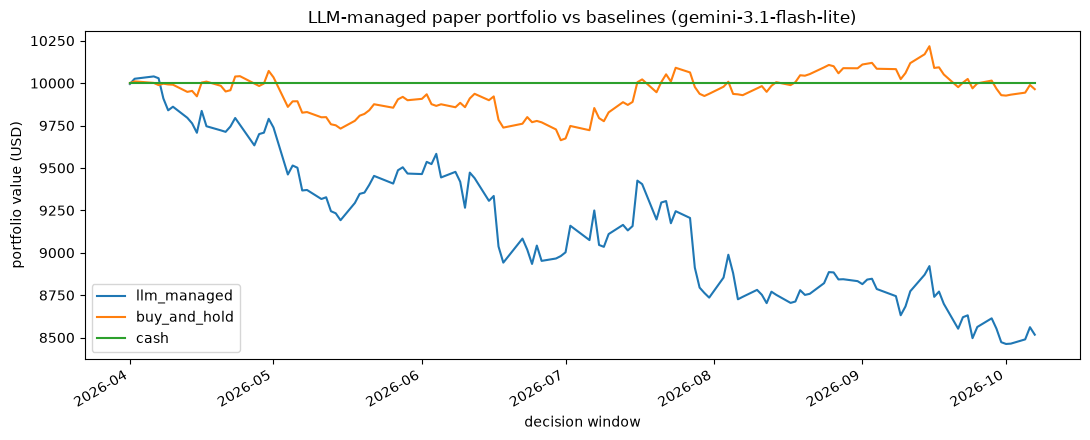

,final value,total return %
llm_managed,8517.17,-14.83
buy_and_hold,9964.28,-0.36
cash,10000.00,0.00


Executed trades: 16 (of 16 requested)
  2026-04-01: sell PG 1250.0 | sell UPS 1250.0 | buy SHEL 1250.0 | buy T 1250.0
  2026-05-01: buy PG 2400 | buy UPS 2400
  2026-06-01: sell PG 2286.32 | sell T 2191.12 | buy SHEL 2238.72 | buy UPS 2238.72
  2026-07-01: sell SHEL 4106 | buy PG 8070
  2026-08-03: sell PG 1200 | buy SHEL 1600
  2026-09-01: sell UPS 1215 | buy T 1215

Verdict (single sample): the model trailed doing nothing (-14.83% vs -0.36% buy-and-hold, +0.00% cash).


In [29]:
load_dotenv(find_env_file())
backtest_key = os.getenv("GEMINI_API_KEY")

if not backtest_key:
    print("GEMINI_API_KEY not set - backtest skipped.")
else:
    from google import genai

    backtest_client = genai.Client(api_key=backtest_key)
    backtest = run_llm_portfolio_backtest(
        BACKTEST_BASKET,
        BACKTEST_DECISION_DATES,
        backtest_prices,
        backtest_client,
        model=BACKTEST_MODEL,
        initial_cash=INITIAL_CASH,
        initial_investment=INITIAL_INVESTMENT,
        transaction_cost=TRANSACTION_COST,
        cash_floor=CASH_FLOOR,
    )

    curve = backtest["equity_curve"]
    ax = curve.plot(title=f"LLM-managed paper portfolio vs baselines ({BACKTEST_MODEL})", figsize=(11, 4.5))
    ax.set_ylabel("portfolio value (USD)")
    ax.set_xlabel("decision window")
    plt.tight_layout()
    plt.show()

    starting_value = INITIAL_CASH + INITIAL_INVESTMENT
    final_table = curve.iloc[-1].to_frame("final value")
    final_table["total return %"] = (final_table["final value"] / starting_value - 1) * 100
    display(final_table.round(2))

    executed = [t for t in backtest["trade_log"] if t["note"] == "executed"]
    print(f"Executed trades: {len(executed)} "
          f"(of {len(backtest['trade_log'])} requested)")
    for entry in backtest["decision_log"]:
        print(f"  {entry['date'].date()}: {entry['reply_preview']}")

    managed_return = final_table.loc["llm_managed", "total return %"]
    passive_return = final_table.loc["buy_and_hold", "total return %"]
    verdict = "beat" if managed_return > passive_return else "trailed"
    print(
        f"\nVerdict (single sample): the model {verdict} doing nothing "
        f"({managed_return:+.2f}% vs {passive_return:+.2f}% buy-and-hold, "
        f"{final_table.loc['cash', 'total return %']:+.2f}% cash)."
    )

## 11. System Validation, Limitations, and Conclusion

### 11.1 System Validation

We perform final validation checks to confirm that the complete workflow executed successfully. These checks verify agent completion, report quality, required report sections, sentiment-model performance, and memory storage.

In [30]:
required_agents = {
    "market_analysis",
    "earnings_analysis",
    "news_analysis"
}

required_report_sections = [
    "executive_summary",
    "market_overview",
    "earnings_overview",
    "news_overview",
    "risk_considerations",
    "disclaimer"
]

validation_results = {
    "System completed": (
        complete_system_result["system_status"] == "Complete"
    ),
    "All specialist agents completed": (
        required_agents.issubset(
            set(complete_system_result["completed_agents"])
        )
    ),
    "Report passed evaluation": (
        complete_system_result["evaluation"]["passed"]
    ),
    "Evaluation met threshold": (
        complete_system_result["evaluation"]["total_score"]
        >= complete_system_result["evaluation"][
            "quality_threshold"
        ]
    ),
    "All report sections present": all(
        complete_system_result["final_brief"].get(section)
        for section in required_report_sections
    ),
    "Sentiment model met 70% accuracy target": (
        accuracy_score(
            y_test,
            sentiment_predictions
        ) >= 0.70
    ),
    "Memory file created": MEMORY_FILE.exists()
}

validation_table = pd.DataFrame(
    {
        "Validation Check": validation_results.keys(),
        "Passed": validation_results.values()
    }
)

display(validation_table)

assert all(validation_results.values()), (
    "One or more system validation checks failed."
)

print("All final validation checks passed.")

,Validation Check,Passed
0,System completed,True
1,All specialist agents completed,True
2,Report passed evaluation,True
3,Evaluation met threshold,True
4,All report sections present,True
5,Sentiment model met 70% accuracy target,True
6,Memory file created,True


All final validation checks passed.


### 11.2 Limitations and Responsible Use

Our system has several important limitations. Yahoo Finance is a dynamic external source, so prices, financial statements, and news results may be delayed, incomplete, or temporarily unavailable. Search results can also include unrelated articles, which is why we added company-specific relevance filtering.

Our sentiment classifier was trained on the Financial PhraseBank dataset. Although it performed well on the test set, short headlines may contain limited context, sarcasm, ambiguous language, or company references that the model does not fully understand. The confidence score helps identify predictions that should be interpreted cautiously.

The market trend is based on historical prices and moving averages. These indicators describe past and current conditions but cannot predict future performance. Quarterly revenue comparisons may also reflect seasonality rather than a lasting change in company performance.

Financial-analysis systems can influence real decisions, so transparency and human review are important. Our report identifies its data sources, includes confidence information and risk considerations, and clearly states that its output is for educational and research purposes rather than personalized financial advice.

### 11.3 Conclusion

In this project, we developed a multi-agent investment research system that coordinates specialized market, earnings, news, evaluator, optimizer, and memory components. The Coordinator Agent creates a research plan and dynamically routes work to the appropriate specialists. The News Analysis Agent demonstrates prompt chaining by ingesting, preprocessing, filtering, classifying, and summarizing financial news.

The Evaluator Agent reviews each completed report with a transparent scoring rubric, while the optimizer improves incomplete reports until they meet the quality threshold. The memory component preserves concise results from previous runs and allows the system to compare current conditions with earlier analyses.

Our final demonstration successfully analyzed Apple, combined live market and financial data with a trained financial sentiment model, generated a complete research brief that passed the quality evaluation, and stored the result for future comparisons. The system demonstrates planning, routing, dynamic tool use, prompt chaining, self-reflection, evaluator–optimizer workflows, and learning across runs.